# Solutions to L12

```{solution} l12-1
:class: dropdown
:label: sol-l12-1
The weak form is $\int u_x v_x + u v dx$.
Letting the matrix of the system be $(a_{ij})_{ij}$, we again see that when $|i - j | > 1$, $a_{ij} = 0$, so our matrix is (again) tridiagonal.
```


```{solution-start} l12-2
:class: dropdown
:label: sol-l12-2
This corresponds to coating an end of the rod in isolating material, meaning that no heat is allowed to flow out of the rod. It can be incorporated into the system of equations by modifying the boundary terms $-u_x(0) v(0) + u_x(1)v(0)$. So if you for example want to enforce $u_x(0) = 0$, just set the term $u_x(0)$ to 0.
```


In [1]:
print("Hello")

Hello


We did this because $a=b$

```{solution-end}
```

```{solution-start} l12-mapping-F
:class: dropdown
:label: sol-l12-mapping-F
We create a convenience function that takes in the coordinates of the vertices of the current cell and the point in the reference element.
```

In [2]:
import basix.ufl
import numpy as np
import matplotlib.pyplot as plt

def compute_physical_point(p0, p1, X):
    """
    Map coordinates `X` in reference element to a line defined by `p0`, `p1`
    """
    el = basix.ufl.element("Lagrange", "interval", 1)
    basis_values = el.tabulate(0, X)
    x = basis_values[0] @ np.vstack([p0, p1])
    return x

cells = np.array([[0,1], [1,2], [2, 3], [3, 4], [4, 6], [6,5]], dtype=np.int64)
nodes = np.array([[0.1], [0.2], [0.4], [0.5],[0.6], [1.], [0.8]], dtype=np.float64)
for cell in cells:
    p0, p1 = nodes[cell]
    X = np.array([[0.5]])
    x = compute_physical_point(p0, p1, X)
    print(f"Cell with vertices {p0}, {p1} has midpoint {x}")

Cell with vertices [0.1], [0.2] has midpoint [[0.15]]
Cell with vertices [0.2], [0.4] has midpoint [[0.3]]
Cell with vertices [0.4], [0.5] has midpoint [[0.45]]
Cell with vertices [0.5], [0.6] has midpoint [[0.55]]
Cell with vertices [0.6], [0.8] has midpoint [[0.7]]
Cell with vertices [0.8], [1.] has midpoint [[0.9]]


```{solution-end}
```
```{solution-start} l12-mapping-tetra-F
:class: dropdown
:label: sol-l12-mapping-tetra-F
We repeat the procedure from earlier and visualize with matplotlib
```

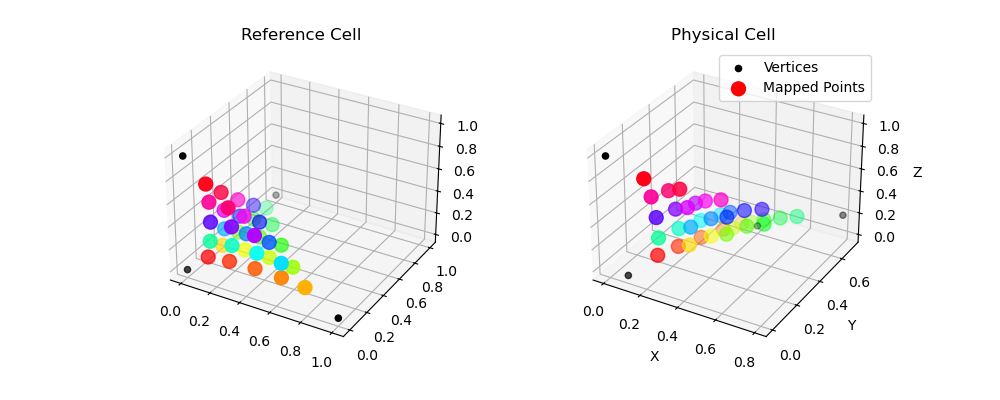

In [3]:
%matplotlib widget
def compute_physical_point(points,cell_type, X):
    """
    Map coordinates `X` in reference element to a cell defined by `points` and `cell_type`
     
    Args:
        points: an array of shape (num_vertices, geometric_dimension)
        cell_type: a string, e.g. "interval", "triangle", "quadrilateral"
        X:is an array of shape (num_points, topological_dimension)
     
    Returns:
        An array of shape (num_points, geometric_dimension)
    """
    el = basix.ufl.element("Lagrange", cell_type, 1)
    basis_values = el.tabulate(0, X)
    return basis_values[0] @ points

points = np.array([[0.1, 0, 0], [0.4, 0.6, 0], [0.8, 0.7, 0.2], [0, 0, 1]], dtype=np.float64)
reference_points = basix.create_lattice(
    basix.CellType.tetrahedron, 8, basix.LatticeType.gll, exterior=False, method=basix.LatticeSimplexMethod.warp
)
node_colors = np.arange(reference_points.shape[0])
X_p = compute_physical_point(points, "tetrahedron", reference_points)
fig,(ax_ref, ax) = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': '3d'})
ref_vertices = basix.geometry(basix.CellType.tetrahedron)
ax_ref.set_title("Reference Cell")
ax_ref.scatter(ref_vertices[:, 0], ref_vertices[:, 1], ref_vertices[:, 2], color='black', label='Vertices')
ax_ref.scatter(reference_points[:, 0], reference_points[:, 1], reference_points[:, 2], c=node_colors, cmap='hsv', s=100)

ax.set_title("Physical Cell")
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='black', label='Vertices')
ax.scatter(X_p[:, 0], X_p[:, 1], X_p[:, 2], label='Mapped Points', cmap='hsv', s=100, c=node_colors)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

```{solution-end}
```

```{solution-start} l12-mapping-detJ
:class: dropdown
:label: sol-l12-mapping-detJ
We create a convenience function for this
```

In [ ]:
def compute_Jacobian(nodes, cell_type, reference_points):
    # Tabulate basis function for the coordinate element
    el = basix.ufl.element("Lagrange", cell_type, 1)
 
    basis_derivatives = el.tabulate(1, reference_points)[1:]
 
    # Compute the basis derivatives in each direction in reference space
    tdim = el.cell.topological_dimension() # Dimension in reference space
    gdim = nodes.shape[1] # Dimension in physical space
    dphi_dxi = []
    for j in range(tdim):
        dphi_dxi.append(basis_derivatives[j] @ nodes)
  
    # The Jacobian is a (gdim, tdim) tensor at each point
    num_points = reference_points.shape[0]
    jacobian = np.transpose(np.hstack(dphi_dxi).reshape(num_points, tdim, gdim), (0, 2, 1))

    # We could alternatively use Einstein summation notation
    dphidx = el.tabulate(1, reference_points[0:1])[1:].reshape(tdim, -1)

    jac0 = np.einsum("ij,ki->jk", nodes, dphidx)
    np.testing.assert_allclose(jacobian[0], jac0)
    return jacobian

# Get some points in the reference element
#X = basix.create_lattice(basix.CellType.triangle, 4, basix.LatticeType.equispaced, exterior=False)
X = np.array([[0.1, 0.2]])
num_points, tdim = X.shape
nodes = np.array([[0, 0, 0], [2, 0, 0.1], [0, 1, 0.2]], dtype=np.float64)
jacobian = compute_Jacobian(nodes, "triangle", X)
print(f"Reference points:\n{X}\nShape: {X.shape}")
print(f"Jacobian:\n{jacobian[0]}")

# For manifold we can use the Gram determinant
jacobian_gram = jacobian[0].T @ jacobian[0]
print(f"Determinant of the Jacobian:\n{np.sqrt(np.linalg.det(jacobian_gram))}")

# Make problem flat surface to use standard determinant
nodes = nodes[:,:2]
jacobian = compute_Jacobian(nodes, "triangle", X)
print(f"Jacobian:\n{jacobian[0]}")
print(f"Determinant of the Jacobian:\n{np.linalg.det(jacobian[0])}")


Reference points:
[[0.1 0.2]]
Shape: (1, 2)
Jacobian:
[[ 2.00000000e+00  7.64210971e-17]
 [-4.30845614e-17  1.00000000e+00]
 [ 1.00000000e-01  2.00000000e-01]]
Determinant of the Jacobian:
2.0420577856662137
Jacobian:
[[ 2.00000000e+00  7.64210971e-17]
 [-4.30845614e-17  1.00000000e+00]]
Determinant of the Jacobian:
2.0


```{solution-end}
```
```{solution-start} l12-stiffness
:class: dropdown
:label: sol-l12-stiffness
We reuse the Jacobian computation from {ref}`sol-l12-mapping-detJ` and focus on computing the reference gradient of our basis functions $\phi_i$ and $\phi_j$. Note that we choose a different function space to describe the unknown that we use to describe the element.
```

In [ ]:

cell_type = basix.CellType.triangle
phi_el = basix.ufl.element("Lagrange", cell_type, 2)
q_points, q_weights = basix.make_quadrature(basix.CellType.triangle, 4)
num_basis_funcs = phi_el.dim
dphidhatx = phi_el.tabulate(1, q_points)[1:] # Shape is (tdim, num_q_points, num_dofs)

def compute_local_stiffness_matrix(cell_nodes):
    # Create local (num_dofs, num_dofs) matrix
    A_local = np.zeros((num_basis_funcs, num_basis_funcs))
    # Compute the jacobian, its inverse and determinant at quadrature points
    jacobian = compute_Jacobian(cell_nodes, cell_type, q_points)
    jacobian_inv = np.linalg.inv(jacobian) # (num_points, tdim, gdim)
    jacobian_inv_T = np.transpose(jacobian_inv, (0, 2, 1)) # (num_points, gdim, tdim)
    detJ = np.abs(np.linalg.det(jacobian))
    # Insert into local tensor
    for i in range(num_basis_funcs):
        for j in range(num_basis_funcs):
            dphidx = np.einsum("ijk,kil->ijl", jacobian_inv_T, dphidhatx) # (num_q_points, gdim, num_dofs)
            grad_product = np.einsum("ij,ij->i", dphidx[:,:,i], dphidx[:,:,j]) # (num_q_points)
            A_local[i, j] += np.sum(q_weights * grad_product * detJ)
    return A_local


In [7]:
nodes = np.array([[0, 0], [2, 0], [0, 1]], dtype=np.float64)
A_e = compute_local_stiffness_matrix(nodes)
print(f"Local stiffness matrix:\n{A_e}")


# Verification with DOLFINx
from mpi4py import MPI
import ufl
import basix.ufl
import dolfinx
cells = np.array([[0,1,2]], dtype=np.int64)
c_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(nodes.shape[1],))
mesh = dolfinx.mesh.create_mesh(MPI.COMM_WORLD,  x=nodes, cells=cells, e=c_el)
V = dolfinx.fem.functionspace(mesh, ("Lagrange", 2))
u, v = ufl.TrialFunction(V), ufl.TestFunction(V)
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
A = dolfinx.fem.assemble_matrix(dolfinx.fem.form(a))
A.scatter_reverse()
np.testing.assert_allclose(A_e, A.to_dense(), rtol=1e-12, atol=1e-14)

Local stiffness matrix:
[[ 1.25000000e+00  8.33333333e-02  3.33333333e-01  2.94209102e-15
  -1.33333333e+00 -3.33333333e-01]
 [ 8.33333333e-02  2.50000000e-01 -1.44051926e-16 -1.94289029e-16
   3.05311332e-16 -3.33333333e-01]
 [ 3.33333333e-01 -1.44051926e-16  1.00000000e+00  1.11022302e-16
  -1.33333333e+00  5.55111512e-17]
 [ 2.94209102e-15 -1.94289029e-16  1.11022302e-16  3.33333333e+00
  -6.66666667e-01 -2.66666667e+00]
 [-1.33333333e+00  3.05311332e-16 -1.33333333e+00 -6.66666667e-01
   3.33333333e+00  2.77555756e-15]
 [-3.33333333e-01 -3.33333333e-01  5.55111512e-17 -2.66666667e+00
   2.77555756e-15  3.33333333e+00]]


```{solution-end}
```

```{solution-start} l12-diffusion-transient
:class: dropdown
:label: sol-l12-diffusion-transient
```

steps =  ['t = 0.0', 't = 0.2', 't = 0.4', 't = 0.6', 't = 0.8', 't = 1.0', 't = 1.2', 't = 1.4', 't = 1.6', 't = 1.8']


/tmp/ipykernel_754/2941096892.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


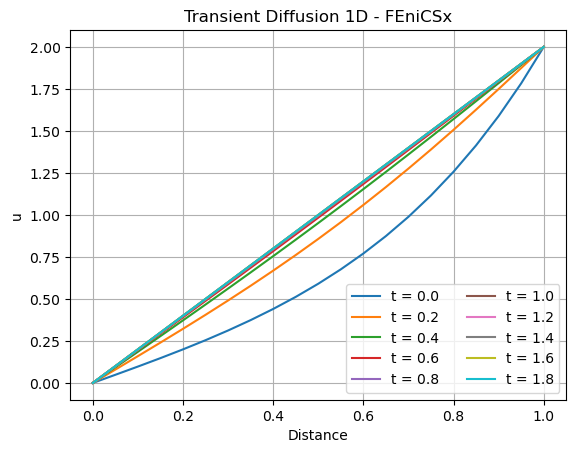

In [4]:
from ufl import TestFunction, TrialFunction, dot, grad, dx
import pyvista
from dolfinx.mesh import create_interval
from dolfinx.fem import Constant, functionspace, Function, locate_dofs_geometrical, dirichletbc
from dolfinx.fem.petsc import LinearProblem
from dolfinx.plot import vtk_mesh
from mpi4py import MPI
import matplotlib.pyplot as plt
import numpy as np

plot_name = "diffusion_1D_transient.png"

# Interval mesh
mesh = create_interval(comm=MPI.COMM_WORLD, nx=20, points=(0, 1))
# Lagrange (CG1) function space
W = functionspace(mesh, ("Lagrange", 1))

# kappa
kappa = Constant(mesh, 1.0)
# Source term
S = Constant(mesh, 0.0)

# Time stepping
dt = 0.2
T = 2
time_steps = np.arange(0, T, dt)
time_steps = time_steps.round(decimals=2)

# Variational form including time derivative
v = TestFunction(W)  # the test function
u = TrialFunction(W)  # the unknown
uh_old = Function(W) # Solution at previous time step. Initialized to zero.

a = (u * v) / dt * dx + kappa * dot(grad(u), grad(v)) * \
    dx  # left hand side of our equation
L = (uh_old * v) / dt * dx + S * v * dx  # right hand side of our equation

# Dirichlet boundary conditions
value_left = Constant(mesh, 0.0)
value_right = Constant(mesh, 2.0)

dofs_left = locate_dofs_geometrical(W, lambda x: np.isclose(x[0], 0))
bc_left = dirichletbc(value_left, dofs_left, W)

dofs_right = locate_dofs_geometrical(W, lambda x: np.isclose(x[0], 1))
bc_right = dirichletbc(value_right, dofs_right, W)

bcs = [bc_left, bc_right]

fig, ax = plt.subplots()
u_grid = pyvista.UnstructuredGrid(*vtk_mesh(W))
plt.xlabel("x")
ax.grid(True)
ax.legend()
problem = LinearProblem(a, L, bcs=bcs, petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
                        petsc_options_prefix="diffusion_1D_transient")
for t in time_steps:
    uh = problem.solve()
    u_grid.point_data["u"] = uh.x.array
    u_grid.plot_over_line([0, 0, 0], [1, 0, 0], resolution=100, figure=False, show=False, title="Transient Diffusion 1D - FEniCSx")
    ax.lines[-1].set_label(f"u({t=:.2f})")

    # update the old solution to the new one for next time step
    uh_old.interpolate(uh)

ax.legend([f"t = {t}" for t in time_steps], ncols=2, loc='lower right')
print("steps = ", [f"t = {t}" for t in time_steps])
plt.show()


```{solution-end}
```